Name: Md. Nafiz Mahmud Shawon
Gmail: work.nafiz@gmail.com

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic_data_updated (1).csv')

# 1

In [ ]:
df.shape

(891, 12)

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
106,107,yes,third,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,NaN,S
365,366,no,third,"Adahl, Mr. Mauritz Nils Martin",male,30.0,0,0,C 7076,7.2500,NaN,S
380,381,yes,first,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C
616,617,no,third,"Danbom, Mr. Ernst Gilbert",male,34.0,1,1,347080,14.4000,NaN,S
445,446,yes,first,"Dodge, Master. Washington",male,4.0,0,2,33638,81.8583,A34,S


# 2

In [ ]:
a = df.isnull().sum().values.sum()
print(f"total missing values is {a}")


total missing values is 866


In [ ]:
x = df.duplicated().sum()
x = int(x)
if x == 0:
  print(f"No duplicate rows.")
else:
  print(f"Found {x} duplicate rows")

No duplicate rows.


In [ ]:
df.drop_duplicates(inplace=True)

# 3

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
"""
-------------------Observation-------------------
১। আমাদের কাছে ১২ টা ফিচার আছে, ৮৯১ টা রেকর্ডস আছে।
২। ফিচারের তত্থের ধরণ [float64(2), int64(3), object(7)] এই আকারে আছে।
৩। কেবিন এ সবচেয়ে বেশি মিসিং তথ্য আছে যা আমাদের জন্য দরকারী না। এটা মডেল কে প্রভাবিত করবে ট্রেন করার সময়।
৪। ভাঁড়ার ক্ষেত্রে datar পার্থক্য অনেক বেশি একদিকে এবং অল্প সংখক এর ভারা দাতাকে আরো বেশি একদিকে প্রভাবিত করছে।
৫। প্যাসেঞ্জের আইডি আমাদের কাজে দিবে না যদিও এটা নিউমেরিকাল তথ্য।
"""

'\n-------------------Observation-------------------\n১। আমাদের কাছে ১২ টা ফিচার আছে, ৮৯১ টা রেকর্ডস আছে।\n২। ফিচারের তত্থের ধরণ [float64(2), int64(3), object(7)] এই আকারে আছে।\n৩। কেবিন এ সবচেয়ে বেশি মিসিং তথ্য আছে যা আমাদের জন্য দরকারী না। এটা মডেল কে প্রভাবিত করবে ট্রেন করার সময়।\n৪। ভাঁড়ার ক্ষেত্রে datar পার্থক্য অনেক বেশি একদিকে এবং অল্প সংখক এর ভারা দাতাকে আরো বেশি একদিকে প্রভাবিত করছে।\n৫। প্যাসেঞ্জের আইডি আমাদের কাজে দিবে না যদিও এটা নিউমেরিকাল তথ্য।\n'

# 4

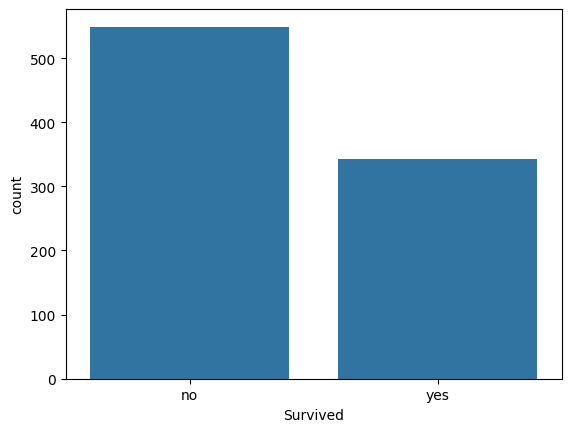

In [ ]:
sns.countplot(data=df, x=df['Survived'])
plt.show()

In [ ]:
info_x = df['Survived'].value_counts()
per_info_x = (df['Survived'].value_counts() / len(df)) * 100

print(info_x)
print(per_info_x)

Survived
no     549
yes    342
Name: count, dtype: int64
Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64


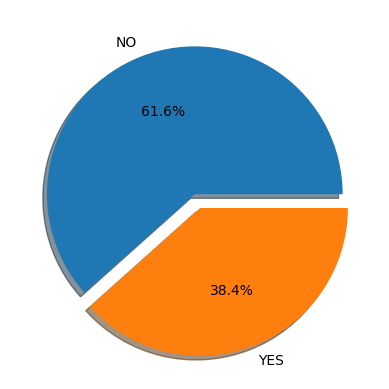

In [ ]:
label = list(str(x).upper() for x in df['Survived'].unique())
plt.pie(info_x, autopct='%1.1f%%', labels= label, shadow=True, explode=[0, 0.1])
plt.show()

In [ ]:
"""
-------------------Observation-------------------
তথ্য অনুযায়ী ৫৪৯ (৬১.৬২%) জন মারা গেছে এবং ৩৪২ (৩৮.৩৯%) জন বেঁচে ফিরেছে।
চাইলে আমরা আরো তথ্য জানতে পারি এখান থেকে অন্য ফিচার এর সাপেক্ষে আপাদত যেটা আমরা করছি না।
"""

'\n-------------------Observation-------------------\nতথ্য অনুযায়ী ৫৪৯ (৬১.৬২%) জন মারা গেছে এবং ৩৪২ (৩৮.৩৯%) জন বেঁচে ফিরেছে।\nচাইলে আমরা আরো তথ্য জানতে পারি এখান থেকে অন্য ফিচার এর সাপেক্ষে আপাদত যেটা আমরা করছি না।\n'

# 5

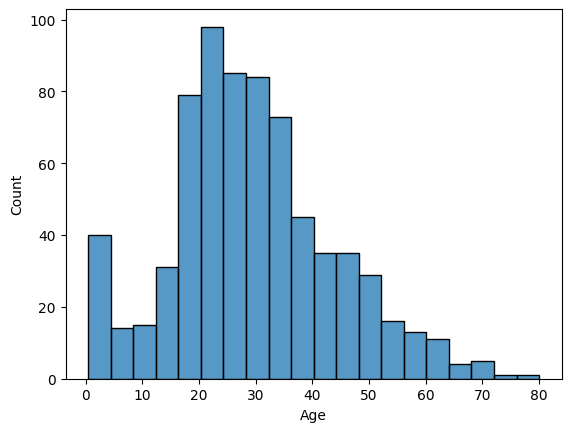

In [ ]:
sns.histplot(data=df, x=df['Age'])
plt.show()

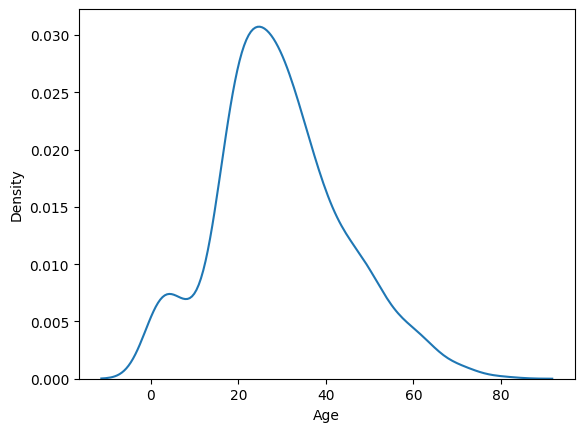

In [ ]:
sns.kdeplot(data=df, x=df['Age'])
plt.show()

In [ ]:
"""
-------------------Observation-------------------
0.7 density er moddhe ekta spike dekha gese jaderr age 1 bochorer o kom.
er theke bujha jay prothomardhe baby der life safe korar jonno kaj korechilo sobai.
kintu porobortite 17-40 er majhe eta distributed hoye jay ebong eder sonkha sobcheye gesi..
amra eta gender er sapekkhe aro details tottho onumna korte parbo

"""

'\n-------------------Observation-------------------\n0.7 density er moddhe ekta spike dekha gese jaderr age 1 bochorer o kom.\ner theke bujha jay prothomardhe baby der life safe korar jonno kaj korechilo sobai.\nkintu porobortite 17-40 er majhe eta distributed hoye jay ebong eder sonkha sobcheye gesi..\namra eta gender er sapekkhe aro details tottho onumna korte parbo\n\n'

# 6

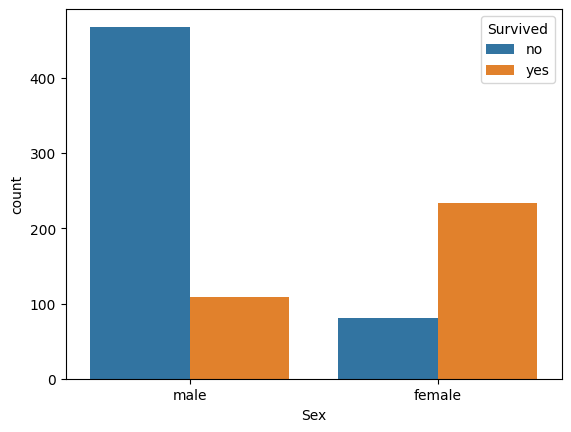

In [ ]:
sns.countplot(data=df, x=df['Sex'], hue=df['Survived'])
plt.show()

In [ ]:
sex_survival = df.groupby('Sex')['Survived'].value_counts(normalize=True)
print(sex_survival * 100)

Sex     Survived
female  yes         74.203822
        no          25.796178
male    no          81.109185
        yes         18.890815
Name: proportion, dtype: float64


In [ ]:
"""
-------------------Observation-------------------
Gender hisebe mohilade survival rate besi purusder tulonay
kintu purush sonkhay onek besi modilader tulonay
"""

'\n-------------------Observation-------------------\nGender hisebe mohilade survival rate besi purusder tulonay\nkintu purush sonkhay onek besi modilader tulonay\n'

# 7

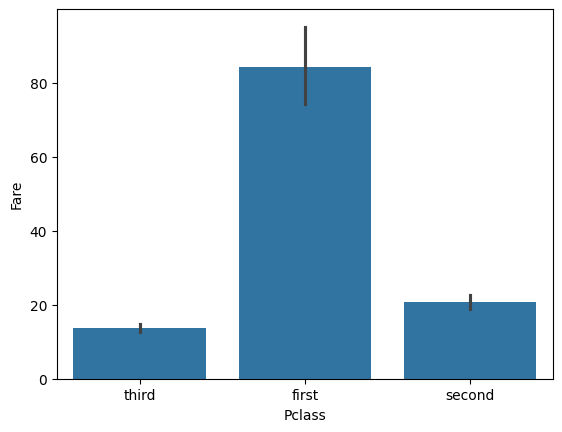

In [ ]:
sns.barplot(data=df, x=df['Pclass'], y=df['Fare'])
plt.show()

In [ ]:
"""
-------------------Observation-------------------
dekha jasse first class er jnno sobcheye besi fare..
second class e ta first cls er tulonay onek kom
third class er tulonay first class er gap onek besi ja amader model kae onek biased kore dibe.
also amra jani fist class e max fare 512.329200 fole ekai onek ta skewed kore dibe ekside .

"""

'\n-------------------Observation-------------------\ndekha jasse first class er jnno sobcheye besi fare..\nsecond class e ta first cls er tulonay onek kom\nthird class er tulonay first class er gap onek besi ja amader model kae onek biased kore dibe.\nalso amra jani fist class e max fare 512.329200 fole ekai onek ta skewed kore dibe ekside .\n\n'

# 8

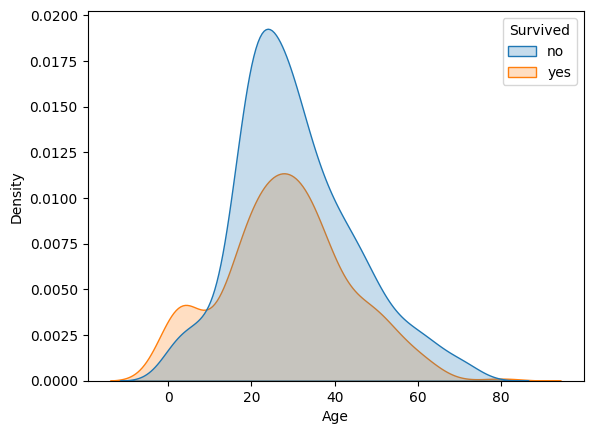

In [ ]:
sns.kdeplot(df, x=df['Age'], hue=df['Survived'], fill=True)
plt.show()

In [ ]:
"""
-------------------Observation-------------------
20 - 35 er moddhe jara chilo tara besi morse
40-80 age er sobar mora ebong bachar har eki hare komse..
0-2 or 5 er majhe sisuder bachar chance besi ekhane ekta hike dekha jasse jekhane sisura beche jay

"""

'\n-------------------Observation-------------------\n20 - 35 er moddhe jara chilo tara besi morse\n40-80 age er sobar mora ebong bachar har eki hare komse..\n0-2 or 5 er majhe sisuder bachar chance besi ekhane ekta hike dekha jasse jekhane sisura beche jay\n\n'

# 9

In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
x = df.drop('Survived', axis=1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape:  {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

x_train shape: (712, 8)
x_test shape:  (179, 8)
y_train shape: (712,)
y_test shape:  (179,)


# 10

In [ ]:
# Imputing missing Age values using SimpleImputer with mean strategy
age_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
age_mean.fit(df[['Age']])
df['Impute_Age'] = age_mean.transform(df[['Age']]).ravel()

# Imputing missing Embarked values using most frequent strategy
embarked_most_frequent = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
embarked_most_frequent.fit(df[['Embarked']])
df['Impute_Embarked'] = embarked_most_frequent.transform(df[['Embarked']]).ravel()

# Imputing missing Cabin values using constant strategy with "Missing"
cabin_constant = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing')
cabin_constant.fit(df[['Cabin']])
df['Impute_Cabin'] = cabin_constant.transform(df[['Cabin']]).ravel()

# Dropping Age, Embarked, Cabin
df.drop(['Age', 'Embarked', 'Cabin'], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
SibSp,0
Parch,0
Fare,0
Impute_Age,0
Impute_Embarked,0
Impute_Cabin,0


### Finally No Missing Values Remain